In [9]:
%pip install torch torchvision torchaudio
%pip install -U matplotlib



Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
%pip install torch torchvision torchaudio tqdm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import zipfile
import os

zip_path = "archive.zip"  
extract_dir = "./archive_extracted"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)


for root, dirs, files in os.walk(extract_dir):
    print(root, len(files), "files")
    
    if root.count(os.sep) - extract_dir.count(os.sep) >= 2:
        break


./archive_extracted 0 files
./archive_extracted\split 0 files
./archive_extracted\split\test 0 files


Type: ['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe']
Sample number: 2929
Training set: 2343, Validation set: 292, Test set: 294


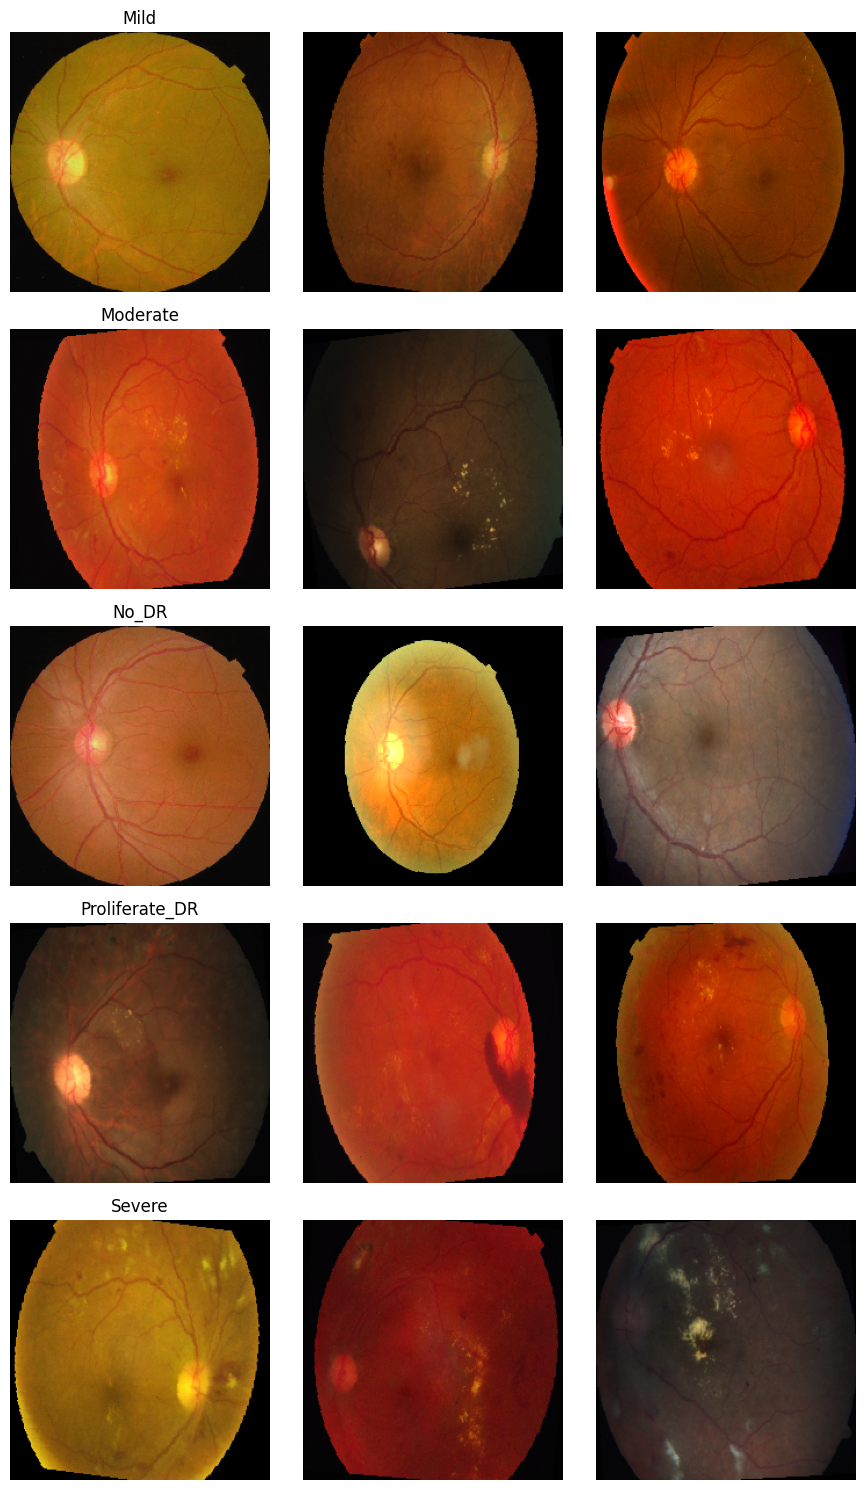

In [12]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader
import matplotlib.pyplot as plt


IMG_SIZE = 224  

# Preprocessing process
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


TRAIN_DIR = "./archive_extracted/split/train"


full_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_tfms)


print("Type:", full_dataset.classes)
print("Sample number:", len(full_dataset))


train_size = int(0.8 * len(full_dataset))  
val_size = int(0.1 * len(full_dataset))    
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)  
)

print(f"Training set: {len(train_dataset)}, Validation set: {len(val_dataset)}, Test set: {len(test_dataset)}")

# -------- Visualize the preprocessed images of each category ----------
def show_images(dataset, classes, num_per_class=3):
    fig, axs = plt.subplots(len(classes), num_per_class, figsize=(num_per_class*3, len(classes)*3))
    
    for class_idx, class_name in enumerate(classes):
        
        indices = [i for i, (_, label) in enumerate(dataset) if label == class_idx]
        chosen = torch.randperm(len(indices))[:num_per_class]  
        for j, idx in enumerate(chosen):
            img, _ = dataset[indices[idx]]
            img = img.permute(1, 2, 0) 
            img = img * torch.tensor([0.229, 0.224, 0.225]) + torch.tensor([0.485, 0.456, 0.406])  
            img = img.clamp(0,1)  
            axs[class_idx, j].imshow(img)
            axs[class_idx, j].axis("off")
            if j == 0:
                axs[class_idx, j].set_title(class_name, fontsize=12)
    
    plt.tight_layout()
    plt.show()

# Display each type of image
show_images(full_dataset, full_dataset.classes, num_per_class=3)


In [13]:
import pickle

splits = {
    "train_idx": train_dataset.indices,
    "val_idx": val_dataset.indices,
    "test_idx": test_dataset.indices,
    "classes": full_dataset.classes
}
with open("dataset_splits.pkl", "wb") as f:
    pickle.dump(splits, f)
print("Saved dataset splits!")


Saved dataset splits!
